# CellFlow performance vs. donor similarity in the training set

For each split in the new-cytokine experiment (with 2–11 donors in training),
we compute the **mean pairwise cosine similarity** among the training donors
using their displacement vectors for the **held-out (test) cytokine only**,
and relate it to CellFlow's energy distance and mean DEG R² via a linear model.

In [11]:
import os
import pickle
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
import statsmodels.api as sm
import matplotlib.pyplot as plt

## 1. Load donor displacement vectors

In [12]:
DATA_DIR = "/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc"

with open(f"{DATA_DIR}/donor_cytokine_displacements.pkl", "rb") as f:
    displacements = pickle.load(f)  # {donor: {cytokine: ndarray(1, 2000)}}

all_donors = sorted(displacements.keys(), key=lambda d: int(d.replace("Donor", "")))
print(f"{len(all_donors)} donors, {len(displacements[all_donors[0]])} cytokines per donor")

12 donors, 90 cytokines per donor


## 2. Load paired metrics and compute cytokine-specific donor similarity per split

In [13]:
df = pd.read_csv(f"{DATA_DIR}/metrics/paired_metrics_new_cytokine.csv")
print(f"Loaded {len(df)} rows")
print(f"num_donors_in_train distribution:")
print(df["num_donors_in_train"].value_counts().sort_index())

Loaded 2596 rows
num_donors_in_train distribution:
num_donors_in_train
0     144
1     374
2     350
3     324
4     288
5     252
6     216
7     180
8     144
9     108
10     72
11    144
Name: count, dtype: int64


In [14]:
def mean_pairwise_similarity_for_cytokine(donors_str, cytokine, displacements):
    """Mean cosine similarity among training donors using displacement for a specific cytokine."""
    if pd.isna(donors_str) or donors_str == "":
        return np.nan
    donors_list = donors_str.split(",")
    if len(donors_list) < 2:
        return np.nan
    vecs = np.stack([displacements[d][cytokine].flatten() for d in donors_list])
    sim = cosine_similarity(vecs)
    # Extract upper triangle (excluding diagonal)
    n = len(donors_list)
    upper = sim[np.triu_indices(n, k=1)]
    return upper.mean()

df["mean_donor_similarity"] = df.apply(
    lambda row: mean_pairwise_similarity_for_cytokine(
        row["donors_in_train_str"], row["cytokine"], displacements
    ),
    axis=1,
)

# Keep only rows where similarity is defined (>= 2 donors in train)
df_fit = df.dropna(subset=["mean_donor_similarity"]).copy()
print(f"{len(df_fit)} rows with >= 2 donors in train (similarity defined)")
print(f"num_donors_in_train range: {int(df_fit['num_donors_in_train'].min())} - {int(df_fit['num_donors_in_train'].max())}")
df_fit[["donor_cytokine", "cytokine", "num_donors_in_train",
        "mean_donor_similarity", "ood_e_distance_cf",
        "mean_deg_r_sq_per_cell_type_cf"]].head(10)

2078 rows with >= 2 donors in train (similarity defined)
num_donors_in_train range: 2 - 11


,donor_cytokine,cytokine,num_donors_in_train,mean_donor_similarity,ood_e_distance_cf,mean_deg_r_sq_per_cell_type_cf
0,Donor4_C5a,C5a,6,0.411775,13.835275,0.873296
2,Donor10_C5a,C5a,11,0.482693,19.943857,0.816124
3,Donor11_4-1BBL,4-1BBL,2,0.086238,10.247426,0.813616
4,Donor6_OSM,OSM,5,0.465105,4.431963,0.880971
6,Donor3_OX40L,OX40L,8,0.451153,2.382911,0.838725
7,Donor3_Noggin,Noggin,5,0.282656,1.950796,0.861379
8,Donor9_IFN-beta,IFN-beta,7,0.639326,18.444820,0.745882
9,Donor6_IFN-epsilon,IFN-epsilon,9,0.676147,5.868563,0.823434
10,Donor9_IFN-beta,IFN-beta,2,0.903458,11.336997,0.754597
13,Donor1_IFN-beta,IFN-beta,11,0.654205,6.390739,0.747497


## 3. Fit linear models

In [15]:
metrics_to_fit = {
    "ood_e_distance_cf": "Energy distance",
    "mean_deg_r_sq_per_cell_type_cf": "Mean DEG $R^2$ per cell type",
}

results = {}
for col, label in metrics_to_fit.items():
    mask = df_fit[col].notna()
    y = df_fit.loc[mask, col]
    X_ols = sm.add_constant(df_fit.loc[mask, "mean_donor_similarity"])
    model = sm.OLS(y, X_ols).fit()
    results[col] = model
    print(f"\n{'='*60}")
    print(f"  {label}  ~  mean donor similarity")
    print(f"{'='*60}")
    print(model.summary())


  Energy distance  ~  mean donor similarity
                            OLS Regression Results                            
Dep. Variable:      ood_e_distance_cf   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     41.79
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.26e-10
Time:                        22:21:39   Log-Likelihood:                -7916.5
No. Observations:                2078   AIC:                         1.584e+04
Df Residuals:                    2076   BIC:                         1.585e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

## 4. Scatter plots with regression line

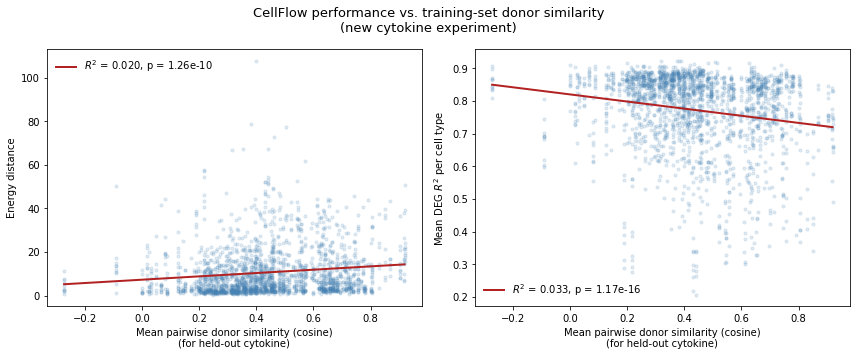

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (col, label) in zip(axes, metrics_to_fit.items()):
    mask = df_fit[col].notna()
    x = df_fit.loc[mask, "mean_donor_similarity"]
    y = df_fit.loc[mask, col]
    model = results[col]

    ax.scatter(x, y, alpha=0.15, s=10, color="steelblue", rasterized=True)

    # Regression line
    x_range = np.linspace(x.min(), x.max(), 100)
    y_pred = model.predict(sm.add_constant(x_range))
    ax.plot(x_range, y_pred, color="firebrick", linewidth=2,
            label=f"$R^2$ = {model.rsquared:.3f}, p = {model.pvalues.iloc[1]:.2e}")

    ax.set_xlabel("Mean pairwise donor similarity (cosine)\n(for held-out cytokine)")
    ax.set_ylabel(label)
    ax.legend(frameon=False)

fig.suptitle("CellFlow performance vs. training-set donor similarity\n(new cytokine experiment)",
             fontsize=13)
plt.tight_layout()
plt.show()